# LLM Fine-Tuning Deep Dive, Part 2 of 3: What Must Riverside Pay to Change?

Part 1 decided **what behavior to practice**. Part 2 asks for the **total bill** of changing the model, not only the compute bill.

For each Riverside adaptation, that bill has three line items:

1. **Update-state bill:** gradients, optimizer state, activations, and training memory.
2. **Artifact bill:** what must be stored, moved, versioned, and loaded for each job.
3. **Capability-regression bill:** testing for catastrophic forgetting, diagnosing lost behavior, rolling back or retraining, and carrying the product cost of degraded instruction following or general capability.

Imagine Riverside wants separate local assistants for fiction editing, marketing campaigns, and author-specific personas. If every adaptation can rewrite the complete model, Riverside may pay all three bills repeatedly: train and store another model, run broader regression suites, and recover any pretrained behavior overwritten by narrow adaptation data.

This notebook follows four attempts to reduce that total bill without changing the learning objective:

1. **Full fine-tuning:** let every weight move, producing the largest update-state and artifact bills and the widest catastrophic-forgetting exposure.
2. **Partial freezing:** reduce update state and protect frozen tensors, while accepting a complete artifact and some remaining regression exposure.
3. **LoRA:** leave the shared base unchanged, store a small correction, and make rollback as simple as disabling the adapter.
4. **QLoRA:** keep that separation while compacting the frozen base when resident memory becomes the blocker.

Each exercise follows the same rhythm:

> Riverside bill -> predict which line items can shrink -> inspect one model object -> run the mechanism -> state what bill remains

The notebook can prove which tensors are writable and what artifacts are saved. That establishes **exposure** to the capability-regression bill. Part 3 measures whether catastrophic forgetting actually occurred and whether its product cost is acceptable.

## Four Questions to Carry Through Every Exercise

1. Which tensors receive gradients, and what update state do they require?
2. Which tensors still participate in the forward pass?
3. What must Riverside save to reconstruct this adaptation?
4. What is the capability-regression bill: which behavior could be lost, how will Riverside detect it, and how easily can it roll back?

## Hardware Boundary

The code reuses the shared SmolLM2 profile: 135M on CPU, 360M on ordinary CUDA, and 1.7B on CUDA with at least 64 GiB. The small CPU path is enough to inspect every mechanism even when generated prose remains unremarkable.

## The Total Bill: Constrain One Line Item at a Time

Riverside fixes the experiment before changing parameter strategy:

| Held constant | Part 2 choice |
| --- | --- |
| Starting checkpoint | The same pinned SmolLM2 instruction checkpoint selected by the hardware profile |
| Data technique | Continued pretraining on raw Aria prose |
| Loss labels | Every real token is supervised; only padding uses `-100` |
| Corpus | *The Weight of Distant Light* only |
| Token budget | 64 positions per training chunk |
| Teaching duration | 10 optimizer steps |
| Capability-regression accounting | Part 3 compares each candidate with the original checkpoint on held-out behavior |

Chat formatting is **not** part of these strategy runs. It appears only in the optional Part 1 SFT-adapter reload and adapter-swapping demonstration, where the model must receive the same chat contract used to train that adapter.

That mismatch creates a real bill. The starting checkpoint knows instruction/chat behavior, while the shared strategy dataset contains only raw fiction prose. Riverside must therefore budget for retention tests even if the target prose metric improves. If retained behavior regresses, the bill grows to include diagnosis, data rebalancing or replay, another training run, artifact replacement, rollback work, and any product impact while the regression is present.

```mermaid
flowchart LR
    F["Full FT\nall base weights can move"] -->|"reduce update state and regression exposure"| P["Partial freezing\nselected layers can move"]
    P -->|"isolate job changes and simplify rollback"| L["LoRA\nfrozen base + small adapter"]
    L -->|"reduce resident-base memory"| Q["QLoRA path\ncompact frozen base + adapter"]
    Q --> E["Part 3\ntarget + retention accounting"]
```

Read the arrows as discovery order, not a required production pipeline.

| Strategy | Update and artifact bills | Capability-regression bill |
| --- | --- | --- |
| Full fine-tuning | Maximum gradient, optimizer, and per-job checkpoint state | Broadest regression surface; rollback means replacing the changed model, and recovery may require retraining |
| Partial freezing | No optimizer state for frozen layers, but still a complete changed checkpoint | Frozen tensors are protected, but the writable slice still requires retention tests and full-artifact rollback |
| LoRA | Small trainable and saved adapter beside one shared base | The base remains recoverable exactly by disabling the adapter; the active adapter still requires behavioral regression tests |
| QLoRA | LoRA-sized update state plus a compact frozen base | Keeps adapter rollback, while adding a separate quality-validation bill for low-bit representation and runtime |

Full FT, partial freezing, and LoRA run the shared raw-text dataset. The CPU QLoRA section remains a structural quantization analogy rather than a fourth complete training run.

This notebook exposes the structural sources of each bill: writable tensors, parameter counts, artifact contents, rollback boundaries, and resident representation. Part 3 determines the actual capability-regression charge by measuring what improved and what was lost.

![Parameter efficiency spectrum comparing full fine-tuning, partial fine-tuning, LoRA, and QLoRA](images/parameter-strategies-spectrum.png)

> **Comparison scope:** Every generated before/after comparison in Part 2 stays on Aria and *The Weight of Distant Light*. The shared eight-novel catalog belongs to later comparison/GPU work and is not required here.

> **PyTorch → Keras:** `AutoModelForCausalLM.from_pretrained(...).to(device)` loads pretrained weights and moves the model to the training device (CPU/GPU); `model.generate()` inside `torch.no_grad()` runs autoregressive decoding without tracking gradients. **Keras/TF equivalent:** `TFAutoModelForCausalLM.from_pretrained(...)` loads weights, with `tf.device(...)` selecting the device; Keras has no built-in `.generate()` for causal LMs outside HF's `TFGenerationMixin.generate()`, and gradient tracking is simply skipped by not wrapping calls in a `tf.GradientTape()`.

## PyTorch Bridge: From Text to a Model Call

Part 2 uses PyTorch, but it needs only one compact execution model. Keep this pipeline in mind when reading the code:

```text
Python string
    -> tokenizer
    -> integer tensors on CPU
    -> move tensors beside the model weights
    -> PyTorch runs tensor operations
    -> output token IDs
    -> tokenizer decodes text
```

### What Is a Tensor?

A **tensor** is a rectangular collection of numbers together with three pieces of execution information:

| Tensor property | Why it matters here | Example |
| --- | --- | --- |
| Shape | Describes how the numbers are arranged | `(batch=1, sequence_length=16)` |
| Data type | Describes what each number represents and how much memory it uses | integer token IDs or floating-point weights |
| Device | Describes which processor and memory currently own the numbers | CPU memory or CUDA GPU memory |

A model's weights are tensors. Token IDs and attention masks are tensors. Activations, logits, losses, and gradients are also tensors. PyTorch layers are mostly organized tensor operations plus registered weight tensors.

### What Does the Tokenizer Return?

The tokenizer does not send text directly into the neural network. With `return_tensors="pt"`, it returns a dictionary of PyTorch tensors:

```text
input_ids       integer vocabulary IDs, shape (batch, sequence)
attention_mask  1 for real positions and 0 for padding, same shape
```

For one unpadded prompt, both tensors commonly have shape `(1, sequence_length)`. The leading `1` is the batch dimension: one sequence is being processed.

### Why Must Inputs Move to the Model's Device?

CPU RAM and GPU memory are separate storage locations. A matrix multiplication cannot directly combine model weights stored in GPU memory with input IDs stored in CPU memory. PyTorch therefore requires tensors participating in an operation to be on compatible devices.

```python
model_device = next(model.parameters()).device
inputs = tokenizer_obj(text_prefix, return_tensors="pt")
inputs = {name: tensor.to(model_device) for name, tensor in inputs.items()}
```

`model.parameters()` iterates over the model's registered weight tensors. `next(...)` reads the first one, and `.device` reports where it lives. The dictionary comprehension then moves each tokenizer tensor to that same device. This assumes the model is normally placed on one device; sharded multi-device inference needs a framework-managed device map instead.

### What PyTorch Does During the Call

When `model.generate(**inputs)` runs, Python orchestrates the call, but optimized PyTorch kernels perform the numerical work on the selected device. During training, PyTorch also records the operations needed for backpropagation. During generation, `torch.no_grad()` tells it not to build that backward graph, reducing memory use.

This chapter uses that contract without re-teaching tensor algebra or autograd. For a hands-on foundation, use [PyTorch RNN Bridge](../../genai-prerequisites/07-pytorch-rnn-bridge/01-pytorch-rnn-bridge.ipynb), especially its token-tensor, device, and explicit training-loop sections.

In [19]:
# Re-establish Part 1's hardware-aware SmolLM2 profile.
from pathlib import Path
import json
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

CUDA_AVAILABLE = torch.cuda.is_available()
GPU_MEMORY_GIB = (
    torch.cuda.get_device_properties(0).total_memory / 1024**3 if CUDA_AVAILABLE else 0.0
)

if not CUDA_AVAILABLE:
    MODEL_PROFILE = "cpu-small-135m"
    INSTRUCT_MODEL_NAME = "HuggingFaceTB/SmolLM2-135M-Instruct"
    INSTRUCT_MODEL_REVISION = "12fd25f77366fa6b3b4b768ec3050bf629380bac"
elif GPU_MEMORY_GIB < 64:
    MODEL_PROFILE = "gpu-balanced-360m"
    INSTRUCT_MODEL_NAME = "HuggingFaceTB/SmolLM2-360M-Instruct"
    INSTRUCT_MODEL_REVISION = "a10cc1512eabd3dde888204e902eca88bddb4951"
else:
    MODEL_PROFILE = "gpu-quality-1.7b"
    INSTRUCT_MODEL_NAME = "HuggingFaceTB/SmolLM2-1.7B-Instruct"
    INSTRUCT_MODEL_REVISION = "31b70e2e869a7173562077fd711b654946d38674"

MODEL_NAME = INSTRUCT_MODEL_NAME
MODEL_REVISION = INSTRUCT_MODEL_REVISION
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]
DEMO_TRAIN_STEPS = 10
STORY_SEED = "Aria Voss stared at the signal counting itself out in prime numbers and"

device = "cuda" if CUDA_AVAILABLE else "cpu"
print(f"Using device: {device} ({MODEL_PROFILE}, {GPU_MEMORY_GIB:.1f} GiB CUDA memory)")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, revision=MODEL_REVISION)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    revision=MODEL_REVISION,
).to(device)
model_config = base_model.config
print(
    f"Loaded {MODEL_NAME}@{MODEL_REVISION[:8]}: {len(base_model.model.layers)} decoder layers, "
    f"hidden size {model_config.hidden_size}, "
    f"{sum(parameter.numel() for parameter in base_model.parameters()):,} parameters"
)
if not CUDA_AVAILABLE:
    print(
        "CPU disclaimer: the 135M checkpoint is large enough to expose freezing, LoRA, and "
        "checkpoint mechanics, but short runs may produce generic or unchanged text. Limited "
        "capacity and ten updates are expected constraints, not evidence against the techniques."
    )


def generate_raw(model, text_prefix, max_new_tokens=60, tokenizer_obj=tokenizer):
    """Continue raw text without adding system, user, or assistant chat markers."""
    model.eval()

    # Tokenize on CPU, then place every input tensor beside the model weights.
    model_device = next(model.parameters()).device
    inputs = tokenizer_obj(text_prefix, return_tensors="pt")
    inputs = {name: tensor.to(model_device) for name, tensor in inputs.items()}
    prompt_len = inputs["input_ids"].shape[1]

    # Generation is inference, so PyTorch does not need to retain a backward graph.
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            top_p=0.9,
            temperature=0.8,
            pad_token_id=tokenizer_obj.pad_token_id,
            eos_token_id=tokenizer_obj.eos_token_id,
        )

    # Hugging Face returns [prompt tokens | generated tokens]. Decode only the new side.
    completion = tokenizer_obj.decode(
        output[0][prompt_len:], skip_special_tokens=True
    ).strip()
    return completion or "[model stopped immediately]"


print(f"Raw baseline continuation (sanity check): {generate_raw(base_model, STORY_SEED)}")

Using device: cpu (cpu-small-135m, 0.0 GiB CUDA memory)


Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3181.79it/s]


Loaded HuggingFaceTB/SmolLM2-135M-Instruct@12fd25f7: 30 decoder layers, hidden size 576, 134,515,008 parameters
CPU disclaimer: the 135M checkpoint is large enough to expose freezing, LoRA, and checkpoint mechanics, but short runs may produce generic or unchanged text. Limited capacity and ten updates are expected constraints, not evidence against the techniques.
Raw baseline continuation (sanity check): , to his surprise, it began to grow larger and more complex. It began to take on a pattern of its own.

The numbers were growing larger and more intricate. They were made up of all the prime numbers in the range, but with an extra 1 added to each. The


In [39]:
# Resolve repository-owned data and artifact paths independently of the kernel's current folder.
def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "learning" / "genai" / "content").is_dir() and (candidate / "checkpoints").is_dir():
            return candidate
    raise FileNotFoundError(
        "Run this notebook from the repository or a descendant directory; "
        "expected learning/genai/content and checkpoints at the repository root."
    )


REPO_ROOT = find_repo_root()
CHECKPOINT_ROOT = REPO_ROOT / "checkpoints"
CHECKPOINT_DIR = CHECKPOINT_ROOT / "llm-finetuning" / MODEL_PROFILE
CONTENT_DIR = REPO_ROOT / "learning" / "genai" / "content"
if not CONTENT_DIR.exists():
    raise FileNotFoundError(
        f"Shared Riverside content directory not found at {CONTENT_DIR.absolute()}. "
        "Expected the GenAI-wide corpus under learning/genai/content."
    )

print(f"Shared content directory: {CONTENT_DIR.absolute()}")
print(f"Profile checkpoints: {CHECKPOINT_DIR.absolute()}")

# Alias -> folder name. Part 2 uses only "scifi"; the wider catalog supports later GPU work.
NOVELS = {
    "scifi": "the-weight-of-distant-light",
    "fantasy": "the-tidebound-accord",
    "mystery": "the-cartographers-cipher",
    "historical": "the-silk-merchants-daughter",
    "cyberpunk": "neural-drift",
    "horror": "the-hollow-beneath",
    "literary": "the-weight-of-tides",
}


def load_corpus_paragraphs(novels=None, min_len=200):
    """Load substantial paragraphs from every chapter of the requested novels."""
    # None means "use the whole catalog"; Part 2 passes ["scifi"] explicitly.
    if novels is None:
        novels = list(NOVELS.keys())

    paragraphs = []
    for alias in novels:
        novel_dir = NOVELS.get(alias)
        if not novel_dir:
            continue  # Ignore an unknown alias rather than constructing an invalid path.

        novel_path = CONTENT_DIR / novel_dir
        if not novel_path.exists():
            continue

        for path in sorted(novel_path.glob("chapter-*.txt")):
            text = path.read_text(encoding="utf-8")
            for paragraph in text.split("\n\n"):
                paragraph = paragraph.strip().replace("\n", " ")
                if len(paragraph) >= min_len:
                    paragraphs.append(paragraph)
    return paragraphs


def tokenize_causal(examples, tokenizer_obj, max_length=64):
    """Turn raw prose into fixed-length causal-LM chunks with padding ignored by loss."""
    tokens = tokenizer_obj(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_overflowing_tokens=True,
    )
    # Each inner list is one training row. Real token IDs become labels; -100 tells
    # Hugging Face's causal-LM loss to skip padding positions.
    tokens["labels"] = [
        [(token if mask == 1 else -100) for token, mask in zip(ids, attention)]
        for ids, attention in zip(tokens["input_ids"], tokens["attention_mask"])
    ]
    return tokens


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from datasets import Dataset
from transformers import Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "font.size": 10})
sns.set_theme(style="whitegrid", palette="muted")

# Build the shared dataset once. Every trainable strategy below reuses this exact object.
STRATEGY_MAX_LENGTH = 64
strategy_paragraphs = load_corpus_paragraphs(novels=["scifi"])
strategy_dataset = Dataset.from_dict({"text": strategy_paragraphs})
strategy_tokenized = strategy_dataset.map(
    # map() passes a batch dictionary such as {"text": [...]}; the lambda supplies
    # the fixed tokenizer and token budget without defining another one-line function.
    lambda examples: tokenize_causal(
        examples, tokenizer, max_length=STRATEGY_MAX_LENGTH
    ),
    batched=True,
    remove_columns=["text"],
)

if not strategy_paragraphs or not strategy_tokenized:
    raise ValueError("The shared Aria strategy dataset is empty")

print("Shared parameter-strategy dataset ready:")
print(f"  objective: raw-text causal language modeling")
print(f"  paragraphs: {len(strategy_paragraphs):,}")
print(f"  tokenized chunks: {len(strategy_tokenized):,}")
print(f"  chunk length: {STRATEGY_MAX_LENGTH}")

Shared content directory: C:\r\ai-portfolio\learning\genai\content
Profile checkpoints: C:\r\ai-portfolio\checkpoints\llm-finetuning\cpu-small-135m


Map: 100%|██████████| 765/765 [00:00<00:00, 4741.18 examples/s]

Shared parameter-strategy dataset ready:
  objective: raw-text causal language modeling
  paragraphs: 765
  tokenized chunks: 1,876
  chunk length: 64


### Hands-On Python Guide: Read the Strategy Code One Move at a Time

The strategy cells reuse a small set of Python ideas. Instead of memorizing syntax, follow what each object contains before and after each operation. The runnable example immediately below uses two sentences and a tiny neural network, so you can inspect the same mechanics without training SmolLM2.

#### 1. Turn Text Rows into Training Rows

The shared setup uses this code:

```python
strategy_dataset = Dataset.from_dict({"text": strategy_paragraphs})
strategy_tokenized = strategy_dataset.map(
    lambda examples: tokenize_causal(
        examples, tokenizer, max_length=STRATEGY_MAX_LENGTH
    ),
    batched=True,
    remove_columns=["text"],
)
```

Read it from the inside out:

1. `{"text": strategy_paragraphs}` is a dictionary with one column named `text`.
2. `Dataset.from_dict(...)` turns that dictionary into a row-based Hugging Face dataset.
3. With `batched=True`, `map()` passes several rows at once as `examples = {"text": [...]}`.
4. The `lambda` is a short function: it forwards that batch to `tokenize_causal` while supplying the fixed `tokenizer` and `STRATEGY_MAX_LENGTH` arguments.
5. `remove_columns=["text"]` drops the original prose after token IDs, attention masks, and labels have been created.

The label-building line inside `tokenize_causal` is a compact loop:

```python
labels = [
    token if mask == 1 else -100
    for token, mask in zip(input_ids, attention_mask)
]
```

`zip(...)` pairs each token with its mask. A real token keeps its ID; a padding token becomes `-100`, which tells the loss function not to score that position.

#### 2. Decide Which Parameters the Optimizer May Change

Partial freezing first disables every parameter:

```python
for parameter in freeze_model.parameters():
    parameter.requires_grad = False
```

It then re-enables only the selected layers:

```python
for layer in decoder_layers[unfreeze_from:]:
    for parameter in layer.parameters():
        parameter.requires_grad = True
```

If a model has 12 blocks and `unfreeze_from == 9`, the slice `decoder_layers[9:]` means blocks 9, 10, and 11. The outer loop visits those blocks; the inner loop visits each block's weight and bias tensors. `requires_grad` changes update permission, not participation in the forward pass: frozen layers still transform the input.

#### 3. Count Values, Not Just Tensor Objects

The strategy cells measure trainable state with:

```python
trainable = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
```

This is equivalent to the longer form:

```python
trainable = 0
for parameter in model.parameters():
    if parameter.requires_grad:
        trainable += parameter.numel()
```

`parameter.numel()` counts the individual numeric values in one tensor. The `if` keeps only writable tensors, and `sum(...)` combines their sizes. A model may expose only a few hundred parameter tensors while those tensors contain millions of values.

#### 4. Hand the Three Required Pieces to `Trainer`

The training cells eventually reduce to this contract:

```python
trainer = Trainer(
    model=freeze_model,
    args=training_args_freeze,
    train_dataset=strategy_tokenized,
)
trainer.train()
freeze_model.save_pretrained(CHECKPOINT_DIR / "partial-freeze")
```

- `model` is the object whose `requires_grad` flags determine what can update.
- `args` controls the run, including batch size, learning rate, and step count.
- `train_dataset` supplies token IDs, attention masks, and labels.
- `train()` performs forward pass, loss calculation, backpropagation, and optimizer steps.
- `save_pretrained(...)` writes the resulting artifact; whether that artifact is a full model or an adapter depends on the model object passed to `Trainer`.

Later adapter portability code uses names to locate one wrapped projection:

```python
q_proj_adapter = next(
    module
    for name, module in swap_model.named_modules()
    if name.endswith("q_proj")
    and hasattr(module, "lora_A")
    and "default" in module.lora_A
)
```

`swap_model.named_modules()` yields each module together with its path-like name. The generator keeps only wrapped query projections that contain the loaded adapter, and `next(...)` returns the first match. The runnable example below uses the same pattern to find the first writable tensor in a tiny model.

Run the next cell and compare each printed result with these four explanations. Then read the full, partial-freezing, and LoRA cells in order; the model is larger, but the Python mechanics are the same.

In [41]:
# Small, inspectable versions of the Python patterns used by the strategy cells.
import torch
from datasets import Dataset

print("1. FROM TEXT ROWS TO TRANSFORMED ROWS")
toy_paragraphs = [
    "Aria listens.",
    "The signal repeats in prime numbers.",
]
toy_dataset = Dataset.from_dict({"text": toy_paragraphs})


def count_words(examples, max_words):
    """Return one derived value for every text row in the incoming batch."""
    return {
        "word_count": [
            min(len(text.split()), max_words)
            for text in examples["text"]
        ]
    }


toy_mapped = toy_dataset.map(
    lambda examples: count_words(examples, max_words=4),
    batched=True,
    remove_columns=["text"],
)
print("Before map:", toy_dataset[:])
print("After map: ", toy_mapped[:])
print("The lambda received a batch, supplied max_words=4, and removed the text column.\n")

print("2. FROM AN ATTENTION MASK TO LOSS LABELS")
toy_input_ids = [314, 2718, 42, 0]
toy_attention_mask = [1, 1, 1, 0]
toy_labels = [
    token if mask == 1 else -100
    for token, mask in zip(toy_input_ids, toy_attention_mask)
]
print("input_ids:      ", toy_input_ids)
print("attention_mask: ", toy_attention_mask)
print("labels:         ", toy_labels)
print("The padded final position becomes -100, so the loss ignores it.\n")

print("3. FREEZE, UNFREEZE, AND COUNT A TINY MODEL")
torch.manual_seed(7)
toy_model = torch.nn.Sequential(
    torch.nn.Linear(4, 3),
    torch.nn.ReLU(),
    torch.nn.Linear(3, 2),
)

# Match the partial-freezing strategy: freeze everything, then reopen one layer.
for parameter in toy_model.parameters():
    parameter.requires_grad = False
for parameter in toy_model[-1].parameters():
    parameter.requires_grad = True

for name, parameter in toy_model.named_parameters():
    print(
        f"{name:<10} shape={str(tuple(parameter.shape)):<8} "
        f"values={parameter.numel():<3} trainable={parameter.requires_grad}"
    )

toy_total = sum(parameter.numel() for parameter in toy_model.parameters())
toy_trainable = sum(
    parameter.numel()
    for parameter in toy_model.parameters()
    if parameter.requires_grad
)
print(f"Total values: {toy_total}; trainable values: {toy_trainable}\n")

print("4. FIND THE FIRST WRITABLE TENSOR")
first_trainable_name, first_trainable_parameter = next(
    (name, parameter)
    for name, parameter in toy_model.named_parameters()
    if parameter.requires_grad
)
print(
    f"next(...) found {first_trainable_name!r} with "
    f"shape {tuple(first_trainable_parameter.shape)}"
)

with torch.no_grad():
    toy_output = toy_model(torch.ones(1, 4))
print("Forward output shape:", tuple(toy_output.shape))
print("no_grad() ran the model without building a backward graph.")

1. FROM TEXT ROWS TO TRANSFORMED ROWS


Map: 100%|██████████| 2/2 [00:00<00:00, 667.14 examples/s]

Before map: {'text': ['Aria listens.', 'The signal repeats in prime numbers.']}
After map:  {'word_count': [2, 4]}
The lambda received a batch, supplied max_words=4, and removed the text column.

2. FROM AN ATTENTION MASK TO LOSS LABELS
input_ids:       [314, 2718, 42, 0]
attention_mask:  [1, 1, 1, 0]
labels:          [314, 2718, 42, -100]
The padded final position becomes -100, so the loss ignores it.

3. FREEZE, UNFREEZE, AND COUNT A TINY MODEL
0.weight   shape=(3, 4)   values=12  trainable=False
0.bias     shape=(3,)     values=3   trainable=False
2.weight   shape=(2, 3)   values=6   trainable=True
2.bias     shape=(2,)     values=2   trainable=True
Total values: 23; trainable values: 8

4. FIND THE FIRST WRITABLE TENSOR
next(...) found '2.weight' with shape (2, 3)
Forward output shape: (1, 2)
no_grad() ran the model without building a backward graph.


---

## Concept 4: Full Fine-Tuning - Maximum Freedom, Maximum Total Bill

### The Riverside Bill: State, Artifacts, and Lost Capability

Full fine-tuning gives every weight permission to change. That is the least constrained way to adapt a model, and it exposes Riverside to all three bill categories:

| Bill line item | What Riverside may pay |
| --- | --- |
| Update state | Gradients and optimizer state across the complete model |
| Artifact operations | Another complete model to store, move, version, deploy, and replace |
| Capability regression | Broader retention tests, diagnosis of lost behavior, rollback or retraining, and product impact from degraded capabilities |

**Catastrophic forgetting** is the failure behind the third line item: useful behavior learned before adaptation regresses because updates for the new task overwrite parameter relationships that supported the old behavior.

The bill is concrete here. Riverside starts from an instruction-tuned checkpoint but trains this experiment only on raw Aria prose. If every base weight follows gradients from that narrow distribution, the model may improve at prose continuation while becoming worse at instruction following, broad language tasks, or knowledge that the adaptation data rarely exercises.

Full fine-tuning does not guarantee forgetting. It creates the widest **billable regression surface** because every parameter is eligible to move. The eventual charge depends on learning rate, step count, data diversity, replay or data mixing, regularization, where the gradients point, and how costly a regression would be in the product.

| What this notebook can establish | What Riverside must still measure and budget for |
| --- | --- |
| Every parameter has `requires_grad=True` | Retention tests across instruction and general capabilities |
| The run uses a small `5e-5` learning rate | Whether the mitigation kept regressions within tolerance |
| Training stops after 10 optimizer steps | Whether another run, replay data, or earlier stopping is needed |
| The original pinned checkpoint remains available | Rollback, artifact replacement, and comparison with the adapted model |

A small learning rate and short run reduce expected drift; they do not erase the capability-regression bill. Production training may also mix representative general/instruction data into adaptation batches, replay retained examples, regularize movement away from the base, evaluate periodically, and stop when retention metrics degrade. Each control consumes engineering or compute budget because forgetting is part of the adaptation bill.

### Make a Prediction

Before counting or training:

- trainable parameters should equal total parameters;
- every transformer block should remain writable;
- the shared raw-text Aria chunks should supervise the same causal-LM objective used by later strategies;
- this should create the largest update-state, artifact, and capability-regression bills; and
- the saved artifact must be a complete changed model, while Part 3 determines the actual regression charge.

### Inspect and Run the Full Reference

The next cell creates a fresh copy of the pinned checkpoint, verifies that every parameter is trainable, runs the shared dataset for ten steps, and saves the complete result. Its small learning rate and short duration are bill-control measures; they do not prove that pretrained behavior survived.

Partial freezing and LoRA reuse the same `strategy_tokenized` rows. The comparison therefore changes where updates can live, how much state is owned per job, and how expensive rollback is.

> **Next bill to reduce:** Can Riverside protect reusable weights so it pays less update state and faces a smaller capability-regression surface?

> **PyTorch → Keras:** `p.numel()` counts elements in each parameter tensor and `p.requires_grad` flags whether it receives gradient updates; summing over `model.parameters()` gives total vs. trainable parameter counts. **Keras/TF equivalent:** `model.count_params()` gives total parameters directly, and the trainable subset is `sum(np.prod(w.shape) for w in model.trainable_weights)` — Keras tracks trainable/non-trainable via each layer's `trainable` attribute rather than a per-tensor `requires_grad` flag.

In [ ]:
# ==============================================================================
# 1. MODEL INITIALIZATION & DEVICE PLACEMENT
# ==============================================================================
# Load a fresh, clean base LLM pinned to a specific git commit/tag (revision).
# Immediately push all weight tensors to the target hardware (GPU or CPU).
full_strategy_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, revision=MODEL_REVISION
).to(device)


# ==============================================================================
# 2. PARAMETER AUDIT (Verifying Full Fine-Tuning)
# ==============================================================================
# parameter.numel() returns the total count of individual numbers inside a tensor matrix.
total_parameters = sum(
    parameter.numel() for parameter in full_strategy_model.parameters()
)

# requires_grad=True tells PyTorch to compute backpropagation gradients for that weight.
trainable_parameters = sum(
    parameter.numel()
    for parameter in full_strategy_model.parameters()
    if parameter.requires_grad
)

trainable_percent = 100 * trainable_parameters / total_parameters

# HARD SANITY CHECK: Ensure 100% of weights are trainable (proves we aren't using LoRA/PEFT here).
assert trainable_parameters == total_parameters


# ==============================================================================
# 3. VERBOSE LOGGING
# ==============================================================================
print("INSPECT FULL FINE-TUNING")
print(f"Training chunks: {len(strategy_tokenized):,}")
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Trainable share: {trainable_percent:.1f}%")
print("Forward pass: complete model")
print("Writable state: complete model")
print("Retention exposure: every base weight can move on the narrow Aria corpus")


# ==============================================================================
# 4. TRAINING CONFIGURATION & EXECUTION
# ==============================================================================
# Full FT moves every base weight. A small learning rate and ten-step run reduce
# update magnitude and exposure to catastrophic forgetting, but cannot prove retention.
training_args_full_strategy = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR / "parameter-full"),
    per_device_train_batch_size=1,  # Kept minimal to reduce peak VRAM usage
    max_steps=DEMO_TRAIN_STEPS,      # Short teaching run; retention still needs evaluation
    logging_steps=1,                 # Log progress every single step
    save_strategy="no",              # Skip intermediate checkpoints to save disk space
    learning_rate=5e-5,
    report_to="none",                # Suppress external logging integrations (like WandB)
)

# Bind the model, config, and dataset into Hugging Face's high-level execution engine
trainer_full_strategy = Trainer(
    model=full_strategy_model,
    args=training_args_full_strategy,
    train_dataset=strategy_tokenized,
)

# Run the training loop and save the full parameter weights to disk
trainer_full_strategy.train()
full_strategy_model.save_pretrained(CHECKPOINT_DIR / "parameter-full")

print("\nAFTER TRAINING")
print("Saved artifact: complete full-fine-tuning checkpoint")
print("Retention status: unmeasured here; Part 3 must compare against the pinned base")
print("Riverside takeaway: maximum update freedom creates the maximum state bill and interference surface.")


# ==============================================================================
# 5. VRAM CLEANUP & GARBAGE COLLECTION
# ==============================================================================
# 1. Break the Python references to free memory allocation in Python's namespace.
del trainer_full_strategy, full_strategy_model

# 2. Force PyTorch to release cached, unused GPU memory back to the system driver
#    so subsequent benchmark runs don't run out of memory (OOM).
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3166.85it/s]


INSPECT FULL FINE-TUNING
Training chunks: 1,876
Total parameters: 134,515,008
Trainable parameters: 134,515,008
Trainable share: 100.0%
Forward pass: complete model
Writable state: complete model


Step,Training Loss
1,3.737514
2,4.089912
3,3.462703
4,4.639843
5,5.268559
6,3.898342
7,4.021924
8,5.201792
9,4.364646
10,4.779439


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.46it/s]


AFTER TRAINING
Saved artifact: complete full-fine-tuning checkpoint
Riverside takeaway: maximum update freedom creates the maximum per-job state bill.


### Riverside Takeaway: What Full Fine-Tuning Bills Riverside

The structural prediction held: every parameter joined the update, and Riverside saved another complete model for this adaptation.

That produces three billed line items:

1. **Update-state bill:** gradients and optimizer state cover the complete model.
2. **Artifact bill:** every fiction, marketing, or author-persona adaptation becomes a complete checkpoint to store, transfer, version, deploy, and replace.
3. **Capability-regression bill:** Riverside must test retained instruction/general behavior; a failure adds diagnosis, rollback, replay or data rebalancing, retraining, redeployment, and product-impact costs.

The code establishes exposure, not the final invoice:

| Observation | Correct accounting conclusion |
| --- | --- |
| `trainable_parameters == total_parameters` | Every weight can contribute to a capability regression |
| `learning_rate=5e-5` and 10 steps | Drift is constrained, but retention testing is still required |
| Training uses only raw Aria prose | Broad instruction behavior is not rehearsed by the adaptation data |
| A complete checkpoint is saved | Rollback is possible by replacing the artifact, but the adapted base itself is rewritten |

Part 3 must compare the pinned base and adapted checkpoint on two axes: did Aria continuation improve, and did held-out instruction/general behavior remain acceptable? The target gain and the capability-regression cost belong on the same decision ledger.

## Concept 5: Partial Freezing - Reuse General Language

### The Riverside Bill: Smaller Update State, Remaining Regression Cost

The base already knows general language. Riverside's next experiment freezes most transformer blocks and updates roughly the last quarter plus the final normalization layer. This removes optimizer state for frozen tensors and guarantees that those tensors remain byte-for-byte unchanged.

Frozen does not mean bypassed: every frozen block still runs during the forward pass and contributes activations to the next block. Freezing changes update permission, not the model's computation path.

Partial freezing reduces the capability-regression bill by narrowing the writable surface, but it does not eliminate it. Riverside still pays for retention tests, and regressions caused by the writable upper layers still require diagnosis and complete-checkpoint rollback or retraining.

### Make a Prediction

- early and middle blocks should have `requires_grad=False`;
- the final block slice should remain trainable;
- update state and the billable regression surface should shrink substantially; but
- the whole model still participates in the forward pass, the writable slice can still alter prior behavior, and the adaptation still saves a complete checkpoint.

The next figure turns that policy into a visible frozen/trainable map before the trainer runs.

### Inspect the Proposed Split Before Training

Riverside's policy is easy to say and easy to implement incorrectly: freeze everything, then re-enable roughly the last quarter of decoder blocks plus `model.norm`. The tied embedding/output weight stays frozen.

| Region | Prediction |
| --- | --- |
| Early and middle transformer blocks | Frozen |
| Last quarter of transformer blocks | Trainable |
| Final normalization | Trainable |
| Tied token embedding / output head | Frozen |

The visualization is a preflight check: if the colors do not match this prediction, Riverside should not spend compute on the run.

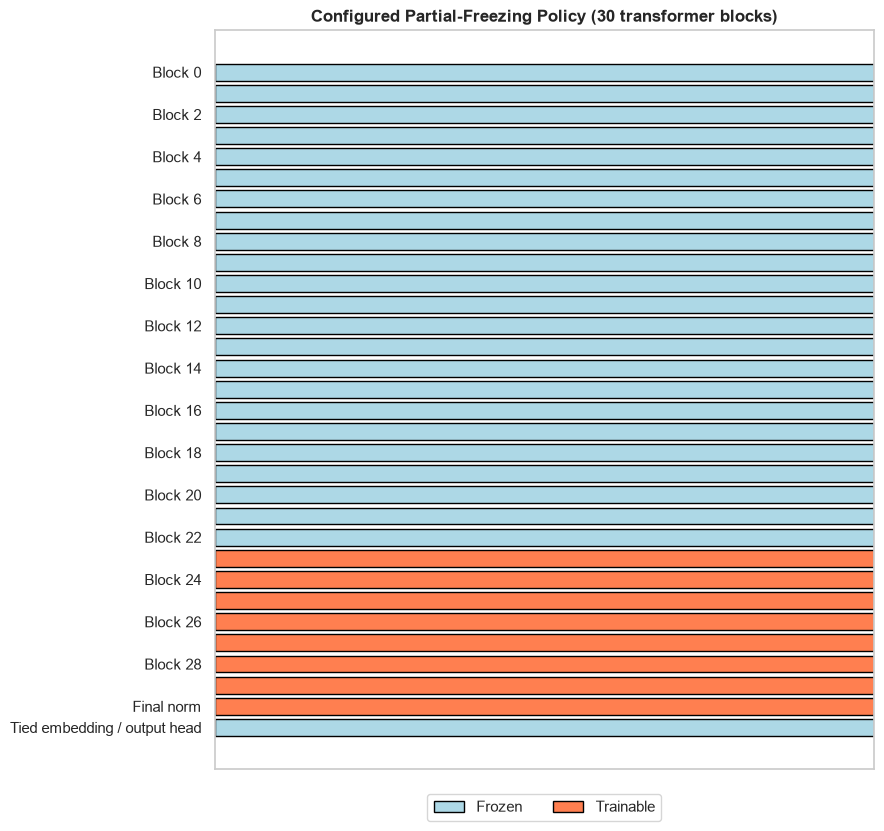

Frozen transformer blocks:    23/30
Trainable transformer blocks: 7/30
Final norm:                   trainable
Tied embedding/output head:   frozen
This policy predicts trainable state, not gradient magnitude or model quality.


In [22]:
# Optional visualization of the configured freezing policy; no gradient values are fabricated.
from transformers import AutoConfig
from matplotlib.patches import Patch

freeze_config = AutoConfig.from_pretrained(MODEL_NAME)
n_layers = freeze_config.num_hidden_layers
unfreeze_from = n_layers - max(2, n_layers // 4)
layers = [f"Block {index}" for index in range(n_layers)] + [
    "Final norm",
    "Tied embedding / output head",
]
trainable_mask = [index >= unfreeze_from for index in range(n_layers)] + [True, False]
colors = ["coral" if is_trainable else "lightblue" for is_trainable in trainable_mask]
positions = np.arange(len(layers))
tick_stride = max(1, n_layers // 12)
tick_positions = list(range(0, n_layers, tick_stride)) + [n_layers, n_layers + 1]

fig, axis = plt.subplots(figsize=(9, max(6, n_layers * 0.28)))
axis.barh(positions, np.ones(len(layers)), color=colors, edgecolor="black")
axis.set_yticks(tick_positions)
axis.set_yticklabels([layers[index] for index in tick_positions])
axis.set_xlim(0, 1)
axis.set_xticks([])
axis.invert_yaxis()
axis.set_title(
    f"Configured Partial-Freezing Policy ({n_layers} transformer blocks)",
    fontweight="bold",
)
axis.legend(
    handles=[
        Patch(facecolor="lightblue", edgecolor="black", label="Frozen"),
        Patch(facecolor="coral", edgecolor="black", label="Trainable"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
)
plt.tight_layout()
plt.show()

frozen_blocks = unfreeze_from
trainable_blocks = n_layers - unfreeze_from
print(f"Frozen transformer blocks:    {frozen_blocks}/{n_layers}")
print(f"Trainable transformer blocks: {trainable_blocks}/{n_layers}")
print("Final norm:                   trainable")
print("Tied embedding/output head:   frozen")
print("This policy predicts trainable state, not gradient magnitude or model quality.")

> **PyTorch → Keras:** setting `param.requires_grad = False` on every parameter freezes the entire model so no gradients flow to it during backprop. **Keras/TF equivalent:** `layer.trainable = False` on each layer (or `model.trainable = False` for the whole model) before compiling — Keras freezes at layer granularity, not per-tensor, and the change only takes effect after the model is (re)compiled.

In [23]:
# Load a fresh base model instance to selectively freeze/unfreeze
freeze_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)

# Start every parameter frozen; the next cell re-enables gradients on the trainable slice
for param in freeze_model.parameters():
    param.requires_grad = False


Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3144.56it/s]


### Selectively Unfreezing the Last ~25% of Blocks

Every parameter starts frozen above. This cell re-enables `requires_grad` only on the last few
`model.layers` blocks (`unfreeze_from` onward) plus `model.norm`, matching the split
visualized earlier. Because `lm_head.weight` is tied to `model.embed_tokens.weight`, both remain
frozen so the optimizer cannot silently update the token embedding through the output head.

> **PyTorch → Keras:** `model.named_parameters()` yields `(name, tensor)` pairs so individual parameters can be selectively re-enabled (`param.requires_grad = True`) by matching name substrings like block index or layer-norm/head names. **Keras/TF equivalent:** iterate `model.layers` and set `layer.trainable = True` for the specific layers you want to unfreeze (matched by `layer.name`), then recompile the model — Keras' selective-unfreezing story works the same way but at whole-layer granularity rather than per-parameter-tensor.

In [24]:
n_layers = len(freeze_model.model.layers)

# Keep roughly the final quarter writable, but always leave at least two blocks trainable.
trainable_block_count = max(2, n_layers // 4)
unfreeze_from = n_layers - trainable_block_count

# Python slicing [unfreeze_from:] means "from this index through the final block."
decoder_layers = freeze_model.model.layers
for layer in decoder_layers[unfreeze_from:]:
    for parameter in layer.parameters():
        parameter.requires_grad = True

# The final normalization sits outside model.layers, so enable it separately.
for parameter in freeze_model.model.norm.parameters():
    parameter.requires_grad = True

# SmolLM2 reuses one tensor for input embeddings and output logits. Leaving that shared
# weight frozen prevents the output head from silently making embeddings writable.
assert freeze_model.lm_head.weight is freeze_model.model.embed_tokens.weight
assert not freeze_model.model.embed_tokens.weight.requires_grad

# str.startswith() accepts a tuple and returns True when any prefix matches.
trainable_layer_prefixes = tuple(
    f"model.layers.{layer_index}."
    for layer_index in range(unfreeze_from, n_layers)
)
for name, parameter in freeze_model.named_parameters():
    belongs_to_trainable_block = name.startswith(trainable_layer_prefixes)
    belongs_to_final_norm = name.startswith("model.norm.")
    if belongs_to_trainable_block or belongs_to_final_norm:
        assert parameter.requires_grad, f"Expected trainable Llama parameter: {name}"

trainable = sum(
    parameter.numel()
    for parameter in freeze_model.parameters()
    if parameter.requires_grad
)
total = sum(parameter.numel() for parameter in freeze_model.parameters())
print(
    f"Partial fine-tuning: {trainable:,}/{total:,} parameters trainable "
    f"({trainable / total * 100:.2f}%)"
)
print("Tied token embedding/output head remains frozen.")

Partial fine-tuning: 24,781,248/134,515,008 parameters trainable (18.42%)
Tied token embedding/output head remains frozen.


### Exercise - Train Only the Selected Slice

**Riverside problem:** the trainability map is configured, but the adaptation has not yet written anything.

**Prediction:** `Trainer` will traverse the complete model during the forward pass but update only tensors whose `requires_grad` flag is enabled. The resulting artifact will still be a complete checkpoint.

**Run:** reuse the causal-language-modeling dataset pattern, train the selected slice for ten steps, and save the full model.

> **PyTorch → Keras:** `Dataset`/`TrainingArguments`/`Trainer.train()` is HF's high-level PyTorch training loop (batching, optimizer, logging all handled internally), and `save_pretrained()` writes the model and config to disk. **Keras/TF equivalent:** `tf.data.Dataset` for batching, `model.compile(optimizer=..., loss=...)` to configure training, `model.fit(dataset, epochs=...)` to run it, and `model.save(...)` / `model.save_weights(...)` to persist — Keras' `fit()` plays the same role as `Trainer.train()`.

In [25]:
# Reuse the exact shared Aria chunks; only the trainable parameter mask changes.
freeze_trainable = sum(
    parameter.numel()
    for parameter in freeze_model.parameters()
    if parameter.requires_grad
)
freeze_total = sum(parameter.numel() for parameter in freeze_model.parameters())

print("BEFORE PARTIAL-FREEZING TRAINING")
print(f"Training chunks: {len(strategy_tokenized):,}")
print(f"Trainable share: {100 * freeze_trainable / freeze_total:.2f}%")
print("Forward pass: complete model")
print("Writable state: selected upper slice")

training_args_freeze = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR / "partial-freeze"),
    per_device_train_batch_size=1,
    max_steps=DEMO_TRAIN_STEPS,
    logging_steps=1,
    save_strategy="no",
    learning_rate=1e-4,
    report_to="none",
)
trainer_freeze = Trainer(
    model=freeze_model,
    args=training_args_freeze,
    train_dataset=strategy_tokenized,
)
trainer_freeze.train()
freeze_model.save_pretrained(CHECKPOINT_DIR / "partial-freeze")

print("\nAFTER TRAINING")
print("Saved artifact: complete partial-freeze checkpoint")
print("Riverside takeaway: update state shrank, but per-job checkpoint duplication remains.")

BEFORE PARTIAL-FREEZING TRAINING
Training chunks: 1,876
Trainable share: 18.42%
Forward pass: complete model
Writable state: selected upper slice


Step,Training Loss
1,3.737514
2,4.090909
3,3.464028
4,4.654531
5,5.276844
6,3.894943
7,4.037461
8,5.198555
9,4.376643
10,4.789229


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.68it/s]


AFTER TRAINING
Saved artifact: complete partial-freeze checkpoint
Riverside takeaway: update state shrank, but per-job checkpoint duplication remains.


## Concept 6: LoRA - Share One Base Across Riverside Jobs

### The Riverside Bill: Small Adapters and Cheap Recovery

Partial freezing reduced update state but still produced a complete changed checkpoint. If Riverside creates fiction, marketing, and author-persona adaptations, it still pays full-artifact storage and replacement costs for every job.

LoRA changes both ownership and recovery. Riverside keeps one frozen base and learns a small correction for each job:

$$
\text{layer output}=Wx+B(Ax).
$$

$W$ is frozen; $BA$ is the learned correction. Rank $r$ is the bottleneck width and limits the independent directions that correction can express.

This changes all three bill lines:

| Bill line item | LoRA effect |
| --- | --- |
| Update state | Gradients and optimizer state cover only the small adapter matrices |
| Artifact operations | Riverside stores one shared base plus a compact adapter per job |
| Capability regression | The active adapter can still alter or degrade outputs, so retention tests remain; however, disabling the adapter restores the unchanged base without replacing or retraining it |

The projection width depends on the selected profile, so the notebook derives it from `base_model.config.hidden_size`. For a square width-$d$ projection, full updating exposes $d^2$ weights while a rank-8 adapter exposes $8d+d8=16d$ weights. The code below prints the actual values for 135M, 360M, or 1.7B instead of assuming a 960-wide model.

![A frozen query projection beside a rank-8 LoRA detour that compresses an activation to eight values, expands it to the runtime hidden width, and adds the correction](images/lora-low-rank-adaptation.png)

### Make a Prediction

- the base projection $W$ should remain frozen;
- only small $A$ and $B$ matrices should receive gradients;
- update state and per-job artifact size should collapse relative to full fine-tuning;
- the active adapter should still require capability-regression tests; and
- rollback should mean disabling or replacing the adapter, not restoring a rewritten base model.

The next cells inspect one real projection, train the adapter, and swap two Riverside adapters onto one compatible base.

> **Next bill to reduce:** the adapter and recovery costs are small, but every job still needs the frozen base resident in memory. Can that shared base be stored more compactly?

> **PyTorch → Keras:** `LoraConfig(...)` declares the LoRA hyperparameters (rank, target modules, alpha), `get_peft_model(base, config)` wraps the frozen base model with trainable low-rank adapter matrices injected into the named target modules, and `print_trainable_parameters()` reports the resulting trainable/total ratio. **Keras/TF equivalent:** no first-party Keras LoRA API exists — the closest honest analog is manually freezing most layers (`layer.trainable = False`) and, for true low-rank adapters, hand-writing a custom `keras.layers.Layer` that adds a `BA` low-rank branch alongside a frozen dense layer; there's no drop-in `get_peft_model` equivalent.

In [26]:
# Inspect the Riverside adapter before training it.
lora_config_pt = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    target_modules=LORA_TARGET_MODULES,
    lora_dropout=0.05,
    bias="none",
)

lora_pt_base = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
lora_pt_model = get_peft_model(lora_pt_base, lora_config_pt)
lora_trainable = sum(
    parameter.numel() for parameter in lora_pt_model.parameters() if parameter.requires_grad
)
lora_total = sum(parameter.numel() for parameter in lora_pt_model.parameters())

print("INSPECT THE LORA UPDATE PATH")
print(f"Target modules: {LORA_TARGET_MODULES}")
print(f"Adapter rank: {lora_config_pt.r}")
print(f"Trainable share: {100 * lora_trainable / lora_total:.4f}%")
print("Base model: frozen and shared")
print("Expected Riverside artifact: adapter only")

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3305.14it/s]


INSPECT THE LORA UPDATE PATH
Target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj']
Adapter rank: 8
Trainable share: 0.6805%
Base model: frozen and shared
Expected Riverside artifact: adapter only


### Exercise 1 - Feed the Shared Objective Through the Adapter

**Riverside problem:** the adapter path exists, but it has not learned a job-specific correction.

**Prediction:** the dataset shape stays identical to causal training, while only LoRA tensors receive updates.

**Run:** build fixed-length chunks from complete selected novels, then send those chunks through the LoRA-wrapped model.

In [27]:
# Reuse the same in-memory dataset object used by full FT and partial freezing.
lora_pt_tokenized = strategy_tokenized

print(
    f"LoRA corpus: {len(strategy_paragraphs):,} paragraphs -> "
    f"{len(lora_pt_tokenized):,} fixed-length training chunks"
)
print(f"Shared chunk length: {STRATEGY_MAX_LENGTH}")
print("Only the update location changes: gradients now land on LoRA matrices.")
print("Part 3 owns behavioral comparison of the resulting artifacts.")

LoRA corpus: 765 paragraphs -> 1,876 fixed-length training chunks
Shared chunk length: 64
Only the update location changes: gradients now land on LoRA matrices.
Part 3 owns behavioral comparison of the resulting artifacts.


### Exercise 2 - Save the Riverside Correction

**Prediction:** `save_pretrained()` should write small adapter files rather than another complete base checkpoint.

**Run:** train for ten steps, save the adapter, and compare its files with the resident base size in the portability exercise below.

> **PyTorch → Keras:** same `TrainingArguments`/`Trainer.train()`/`save_pretrained()` pattern as the earlier training cell, here training only the LoRA adapter's parameters (the base stays frozen) and saving just the small adapter weights. **Keras/TF equivalent:** `model.compile(...)` + `model.fit(...)` with only the adapter sublayer's `trainable = True`, then `model.save_weights(...)` — since Keras has no adapter abstraction, this would typically save the whole model rather than a separate small adapter file.

In [28]:
# Train only the LoRA correction, then inspect the saved Riverside artifact.
training_args_lora_pt = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR / "peft-lora"),
    per_device_train_batch_size=1,
    max_steps=DEMO_TRAIN_STEPS,  # short instructional run; increase for a real convergence study
    logging_steps=1,
    save_strategy="no",
    learning_rate=2e-4,
    report_to="none",
)

# Wire the LoRA-wrapped model, its training args, and the tokenized dataset together
trainer_lora_pt = Trainer(
    model=lora_pt_model, args=training_args_lora_pt, train_dataset=lora_pt_tokenized
)

# Run training -- only the LoRA adapter matrices actually receive gradient updates
trainer_lora_pt.train()

# Persist just the small adapter weights (the frozen base isn't re-saved)
lora_artifact_dir = CHECKPOINT_DIR / "peft-lora"
lora_pt_model.save_pretrained(str(lora_artifact_dir))
lora_artifact_bytes = sum(
    path.stat().st_size for path in lora_artifact_dir.iterdir() if path.is_file()
)
print("RIVERSIDE LORA ARTIFACT")
print(f"Trainable values: {lora_trainable:,}")
print(f"Saved adapter files: {lora_artifact_bytes / 1024:.0f} KiB")
print("Frozen base files were not copied into this adapter directory.")


Step,Training Loss
1,3.737514
2,4.101243
3,3.461951
4,4.646284
5,5.280023
6,3.891446
7,4.028147
8,5.203916
9,4.379025
10,4.793323


RIVERSIDE LORA ARTIFACT
Trainable values: 921,600
Saved adapter files: 3637 KiB
Frozen base files were not copied into this adapter directory.


### Optional Depth: Visualize the Low-Rank Correction

The main practical path needs only the measured parameter count and a compatible adapter. The next visualization reads the selected SmolLM2 hidden width at runtime and draws its rank-8 $A$ and $B$ path.

Use this section when you want to see why the correction has rank at most $r$. Otherwise, continue to **Reload Part 1's Instruction Adapter for the Swap**.

The code computes the full-projection and adapter counts from the loaded model, so the figure remains accurate for the 135M CPU, 360M GPU, and 1.7B high-memory GPU profiles.

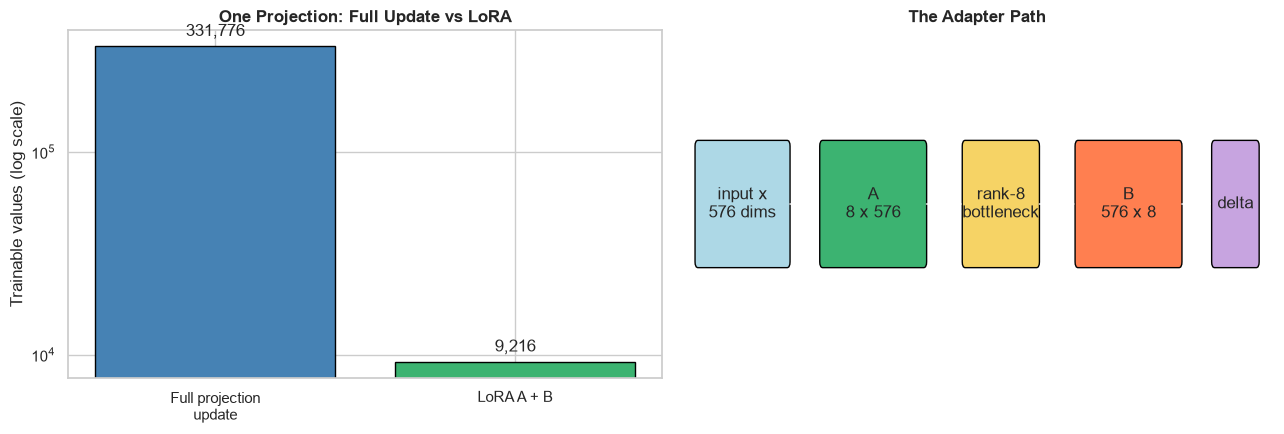

Full projection update: 331,776 trainable values
LoRA rank-8: A=4,608 + B=4,608 = 9,216 (2.78% of the full projection)
This comparison measures adapter capacity, not peak memory, speed, or quality.


In [29]:
# Optional shape-and-count view of one SmolLM2 projection.
from matplotlib.patches import FancyBboxPatch

projection_width = base_model.config.hidden_size
adapter_rank = 8
full_projection_params = projection_width * projection_width
adapter_a_params = adapter_rank * projection_width
adapter_b_params = projection_width * adapter_rank
adapter_total_params = adapter_a_params + adapter_b_params
adapter_percent = adapter_total_params / full_projection_params * 100

fig, (count_axis, path_axis) = plt.subplots(1, 2, figsize=(13, 4.5))

labels = ["Full projection\nupdate", "LoRA A + B"]
counts = [full_projection_params, adapter_total_params]
count_axis.bar(labels, counts, color=["steelblue", "mediumseagreen"], edgecolor="black")
count_axis.set_yscale("log")
count_axis.set_ylabel("Trainable values (log scale)")
count_axis.set_title("One Projection: Full Update vs LoRA", fontweight="bold")
for index, count in enumerate(counts):
    count_axis.text(index, count * 1.08, f"{count:,}", ha="center", va="bottom")

path_axis.set_xlim(0, 10)
path_axis.set_ylim(0, 3)
path_axis.axis("off")
boxes = [
    (0.3, 1.0, 1.5, 1.0, f"input x\n{projection_width} dims", "lightblue"),
    (2.4, 1.0, 1.7, 1.0, f"A\n{adapter_rank} x {projection_width}", "mediumseagreen"),
    (4.8, 1.0, 1.2, 1.0, f"rank-{adapter_rank}\nbottleneck", "#f6d365"),
    (6.7, 1.0, 1.7, 1.0, f"B\n{projection_width} x {adapter_rank}", "coral"),
    (9.0, 1.0, 0.7, 1.0, "delta", "#c7a4e0"),
]
for x_pos, y_pos, width, height, label, color in boxes:
    path_axis.add_patch(
        FancyBboxPatch(
            (x_pos, y_pos),
            width,
            height,
            boxstyle="round,pad=0.05",
            facecolor=color,
            edgecolor="black",
        )
    )
    path_axis.text(x_pos + width / 2, y_pos + height / 2, label, ha="center", va="center")
for start, end in [(1.8, 2.4), (4.1, 4.8), (6.0, 6.7), (8.4, 9.0)]:
    path_axis.annotate("", xy=(end, 1.5), xytext=(start, 1.5), arrowprops={"arrowstyle": "->"})
path_axis.set_title("The Adapter Path", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Full projection update: {full_projection_params:,} trainable values")
print(
    f"LoRA rank-{adapter_rank}: A={adapter_a_params:,} + B={adapter_b_params:,} "
    f"= {adapter_total_params:,} ({adapter_percent:.2f}% of the full projection)"
)
print("This comparison measures adapter capacity, not peak memory, speed, or quality.")

### Reload Part 1's Instruction Adapter for the Swap

The parameter-strategy exercises above used raw Aria prose with causal next-token labels. Chat formatting is needed only now, when Riverside reconstructs Part 1's SFT adapter and compares it with the raw-prose adapter on one shared base.

Artifacts live under `checkpoints/llm-finetuning/<profile>/`. Run Part 1 on the same hardware profile before this reload. The compatibility check below stops rather than attaching an adapter from another model size.

On CPU, the 135M adapter may still generate generic or unchanged text after the ten-step teaching run. That is expected because model capacity and optimization time are deliberately small; the adapter structure, trainable-parameter count, and checkpoint contract remain valid learning evidence.

> **PyTorch → Keras:** `PeftModel.from_pretrained(base_model, adapter_dir)` attaches previously trained LoRA adapter weights on top of a frozen base model. Keras has no first-party PEFT loader; the closest equivalent is reconstructing a compatible frozen-base-plus-adapter model and loading its weights explicitly.

In [33]:
# Chat formatting is defined here because only the SFT adapter uses this contract.
SYSTEM_PROMPT = "You are Riverside House's concise fiction-writing assistant."
INSTRUCTION_PROMPT = "Continue this fiction narrative in the same style: " + STORY_SEED


def format_instruction(prompt, tokenizer_obj=tokenizer):
    """Serialize system and user messages with SmolLM2's native chat markers."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt.strip()},
    ]
    return tokenizer_obj.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


def generate_instruction(
    model, prompt, max_new_tokens=60, tokenizer_obj=tokenizer
):
    """Generate from a chat-formatted prompt using the shared low-level decoder."""
    serialized_prompt = format_instruction(prompt, tokenizer_obj)
    # generate_raw() does not add roles; here it receives text that is already serialized.
    return generate_raw(
        model,
        serialized_prompt,
        max_new_tokens=max_new_tokens,
        tokenizer_obj=tokenizer_obj,
    )


# Refuse to attach an adapter trained for a different SmolLM2 profile.
instruction_adapter_dir = CHECKPOINT_DIR / "instruction-lora"
adapter_config_path = instruction_adapter_dir / "adapter_config.json"
if not adapter_config_path.is_file():
    raise FileNotFoundError(
        f"Missing {adapter_config_path}. Rerun Part 1 with MODEL_NAME={MODEL_NAME!r}."
    )

saved_adapter_config = json.loads(adapter_config_path.read_text(encoding="utf-8"))
saved_base = saved_adapter_config.get("base_model_name_or_path")
if saved_base != MODEL_NAME:
    raise RuntimeError(
        f"Checkpoint base {saved_base!r} is incompatible with {MODEL_NAME!r}. "
        "Leave the old artifact untouched and regenerate Part 1 checkpoints."
    )

instruct_base_reload = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, revision=MODEL_REVISION
).to(device)
instruct_lora_model = PeftModel.from_pretrained(
    instruct_base_reload, instruction_adapter_dir
).to(device)
instruct_lora_model.eval()
print("Reloaded the SmolLM2 instruction adapter generated by Part 1.")
print(generate_instruction(instruct_lora_model, INSTRUCTION_PROMPT))

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3071.08it/s]


Reloaded the SmolLM2 instruction adapter generated by Part 1.
In the dimly lit study, Aria Voss, the enigmatic and enigmatic editor, sat in a haze of cigarette smoke and the faint scent of smoke. She'd been tasked with writing a sweeping treatise on the art of writing, but this was her first major assignment. Her name had been etched


### Adapter Portability: Swapping Onto a Compatible Base

LoRA adapters are swappable because they store small deltas rather than another complete base model. Compatibility is strict: the target module names, tensor dimensions, tokenizer contract, base model identifier, and selected hardware profile must agree.

The code below uses the profile-selected SmolLM2 instruction checkpoint and adapters regenerated by Parts 1 and 2 under the same profile directory. An adapter from the 135M, 360M, or 1.7B profile cannot be attached to either of the other sizes even though all three use Llama-style projection names.

This is why profile selection happens before checkpoint paths are resolved and why old artifacts are never overwritten or silently migrated.

> **PyTorch → Keras:** `PeftModel.from_pretrained(...)` attaches one adapter to a base model, `load_adapter(...)` registers a second adapter on the same base without reloading its weights, and `set_adapter(...)` switches which adapter's deltas are active — all cheap pointer/dict operations inside PEFT's routing layer. **Keras/TF equivalent:** no built-in adapter-swapping mechanism exists; the practical substitute is keeping separate fully fine-tuned (or separately frozen/unfrozen) model copies and calling `model.load_weights(...)` to switch between them, which is far more expensive than PEFT's adapter swap since it reloads full weight sets rather than a tiny delta.

In [34]:
import gc
import os
from peft import PeftModel

# Load the shared base once. Adapters below add small job-specific corrections.
swap_base = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, revision=MODEL_REVISION
).to(device)
swap_model = PeftModel.from_pretrained(
    swap_base, CHECKPOINT_DIR / "peft-lora"
)
swap_model.eval()

adapter_kb = sum(
    os.path.getsize(os.path.join(CHECKPOINT_DIR / "peft-lora", filename))
    for filename in os.listdir(CHECKPOINT_DIR / "peft-lora")
) / 1024
base_mb = sum(
    parameter.numel() * parameter.element_size()
    for parameter in swap_base.parameters()
) / 1024**2
print(f"Base model in memory: {base_mb:.0f} MB (shared across adapters)")
print(f"Continued-pretraining adapter on disk: {adapter_kb:.0f} KB")

# The default adapter learned from raw prose, so probe it with an unformatted text prefix.
print()
print("[Continued-pretraining adapter]")
print(f"  {generate_raw(swap_model, STORY_SEED)}")

# Register the SFT adapter under a readable name, then activate it without reloading the base.
swap_model.load_adapter(
    CHECKPOINT_DIR / "instruction-lora", adapter_name="instruct"
)
swap_model.set_adapter("instruct")
print()
print("[Instruction adapter]")
print(f"  {generate_instruction(swap_model, INSTRUCTION_PROMPT)}")

# Switch back by name; only the active low-rank correction changes.
swap_model.set_adapter("default")
print()
print("[Continued-pretraining adapter, restored]")
print(f"  {generate_raw(swap_model, STORY_SEED)}")

# next(...) returns the first wrapped query projection that owns the default adapter.
q_proj_adapter = next(
    module
    for name, module in swap_model.named_modules()
    if name.endswith("q_proj")
    and hasattr(module, "lora_A")
    and "default" in module.lora_A
)
q_proj_A_shape = tuple(q_proj_adapter.lora_A["default"].weight.shape)
print()
print(f"q_proj LoRA A shape: {q_proj_A_shape}")
print(
    f"Compatibility contract: base={MODEL_NAME}, "
    f"hidden_size={swap_model.config.hidden_size}, targets={LORA_TARGET_MODULES}"
)
print(
    "Adapters from another model size must be regenerated; "
    "checkpoint files are not converted in place."
)

del swap_base, swap_model
gc.collect()

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 2542.73it/s]


Base model in memory: 260 MB (shared across adapters)
Continued-pretraining adapter on disk: 3637 KB

[Continued-pretraining adapter]
  then stopped.

"How many are in the first ten?" she asked.

"Four," he said.

"And what about the eleventh?"

"The eighth," he said.

"And the ninth?"

"No," she said. "No

[Instruction adapter]
  The signal count, a stark, black-and-white, mathematical grid, its numbers, digits, and patterns, were a reminder that this was no ordinary number series. Aria's gaze narrowed, taking in every detail. The sequence was a cycle, a cyclical pattern that repeated, but it

[Continued-pretraining adapter, restored]
  the words "the last one" and "the last one" repeated. She turned to her friend and asked, "And how are you doing today? Are you feeling the need to go to work?"

"I'm feeling a bit... anxious," she replied, her voice barely above a

q_proj LoRA A shape: (8, 576)
Compatibility contract: base=HuggingFaceTB/SmolLM2-135M-Instruct, hidden_size=576, targets=

33698

## Concept 7: QLoRA - Make the Shared Base Fit

### The Riverside Bill: Base Residency and Low-Bit Verification

LoRA reduced per-job update state, artifact size, and recovery cost, but not resident base memory. On a much larger checkpoint, Riverside may be unable to fit even the frozen base beside activations and the adapter.

QLoRA combines a compact frozen base representation with floating-point LoRA matrices. It keeps LoRA's recovery boundary: adapter training does not rewrite the shared base. However, low-bit representation adds its own validation bill because quantization can change outputs even when no pretrained weight is being updated.

![One activation splitting into a frozen base path stored as four-bit codes with shared scales and reconstructed only for computation, and a trainable LoRA path whose correction rejoins the base output while gradients update only the adapter](images/qlora-quantized-base-lora-adapters.png)

Read the diagram as two paths through the same layer:

1. **Frozen base path:** compact codes and scale values represent the base weights in memory; the runtime reconstructs compute-friendly values for multiplication.
2. **Trainable adapter path:** LoRA $A$ and $B$ remain floating-point parameters and receive gradients.
3. **Addition:** the base output and adapter correction are added exactly as in ordinary LoRA.

The common four-bit format is **NF4**. Storage precision and arithmetic precision are separate choices: compact codes can represent the frozen base while computation uses a wider type.

```mermaid
flowchart LR
    X["Activation"] --> BASE["Reconstruct frozen base weights<br/>for this computation"]
    CODES["Compact frozen codes<br/>+ scales"] --> BASE
    X --> A["Trainable LoRA A"] --> B["Trainable LoRA B"]
    BASE --> ADD(("Add"))
    B --> ADD
    ADD --> Y["Layer output"]
```

During backpropagation, gradients pass through the base computation to earlier activations, but the frozen codes do not update. Optimizer state is needed only for the LoRA matrices.

QLoRA therefore separates two possible capability charges:

- **catastrophic-forgetting bill:** still bounded by adapter-only updates and cheap adapter rollback;
- **quantization-quality bill:** requires comparison with the full-precision base because compact representation may introduce a distinct regression.

### Make a Prediction

In the CPU analogy below, compact integer codes should reconstruct a compute-friendly base weight, the base should remain frozen, and gradients should appear only on the floating-point LoRA matrices. The analogy can prove separation of update paths, not production NF4 quality.

### Inspect the Two Paths

The next cell uses a tiny uniform four-bit approximation because this notebook runs without a CUDA-specific QLoRA stack. It demonstrates compact codes, reconstruction, a floating-point adapter branch, and gradients landing only on the adapter. It is not NF4 or a trained QLoRA checkpoint.

For this small SmolLM2 profile, ordinary LoRA is the practical local path. QLoRA adds value only when frozen-base memory is the bill that blocks deployment.

The deeper kernel and format details belong in [Quantization in Depth](../../ai-infrastructure/06-quantization/quantization-in-depth.ipynb#appendix-b-nf4-and-qlora).

In [35]:
# CPU-only structural analogy: uniform 4-bit codes, not bitsandbytes NF4.
torch.manual_seed(7)
in_features, out_features, rank = 4, 3, 2
alpha = 4

activation = torch.randn(2, in_features)
base_weight = torch.randn(out_features, in_features)  # frozen reference weights

# Approximate each output row with signed 4-bit codes and one scale.
scale = base_weight.abs().amax(dim=1, keepdim=True).clamp_min(1e-8) / 7
quantized_codes = torch.clamp(torch.round(base_weight / scale), -8, 7).to(torch.int8)
reconstructed_weight = quantized_codes.float() * scale

# Only these small floating-point matrices are trainable.
lora_a = torch.nn.Parameter(torch.randn(rank, in_features) * 0.05)
lora_b = torch.nn.Parameter(torch.randn(out_features, rank) * 0.05)

base_output = activation @ reconstructed_weight.T
adapter_output = (activation @ lora_a.T) @ lora_b.T * (alpha / rank)
layer_output = base_output + adapter_output
layer_output.square().mean().backward()

assert base_weight.grad is None
assert lora_a.grad is not None and lora_b.grad is not None
print("INSPECT THE QLORA TWO-PATH ANALOGY")
print(f"Stored frozen-base codes: {quantized_codes.dtype}")
print(f"Reconstructed compute weights: {reconstructed_weight.dtype}")
print(f"Frozen base gradient: {base_weight.grad}")
print(f"LoRA gradient norms: A={lora_a.grad.norm():.4f}, B={lora_b.grad.norm():.4f}")
print(f"Toy reconstruction MAE: {(base_weight - reconstructed_weight).abs().mean():.4f}")
print("Riverside takeaway: compact base storage and trainable job adapters are separate paths.")


INSPECT THE QLORA TWO-PATH ANALOGY
Stored frozen-base codes: torch.int8
Reconstructed compute weights: torch.float32
Frozen base gradient: None
LoRA gradient norms: A=0.2109, B=0.7148
Toy reconstruction MAE: 0.0561
Riverside takeaway: compact base storage and trainable job adapters are separate paths.


### Riverside Synthesis - Which Bills Did Each Strategy Reduce?

Return to the question that opened the notebook: what is the total cost of each adaptation?

The trained objects support direct accounting for two line items: how many values receive updates and how much gradient-plus-Adam state those values imply under an fp32 proxy. They also expose the recovery boundary: full and partial fine-tuning save changed base checkpoints, while LoRA preserves the shared base and isolates change in an adapter.

The chart below measures update-state cost only. It does **not** measure the capability-regression bill. Part 3 must add retention-test results, remediation effort, and rollback complexity to the same decision ledger.

Predict the structural ordering before running the chart:

- full fine-tuning should have the largest measured update-state bill and broadest regression exposure;
- partial freezing should reduce both surfaces but retain complete-checkpoint recovery cost;
- LoRA should reduce update state dramatically and make rollback adapter-local; and
- QLoRA is omitted from this chart because its extra savings concern frozen-base residency, while its low-bit quality bill needs separate evaluation.

> **PyTorch → Keras:** PyTorch counts trainable values with `sum(p.numel() for p in model.parameters() if p.requires_grad)`. The Keras equivalent is `sum(np.prod(weight.shape) for weight in model.trainable_weights)`. In either framework, parameter counts support an update-state estimate only; they do not measure peak memory or speed.

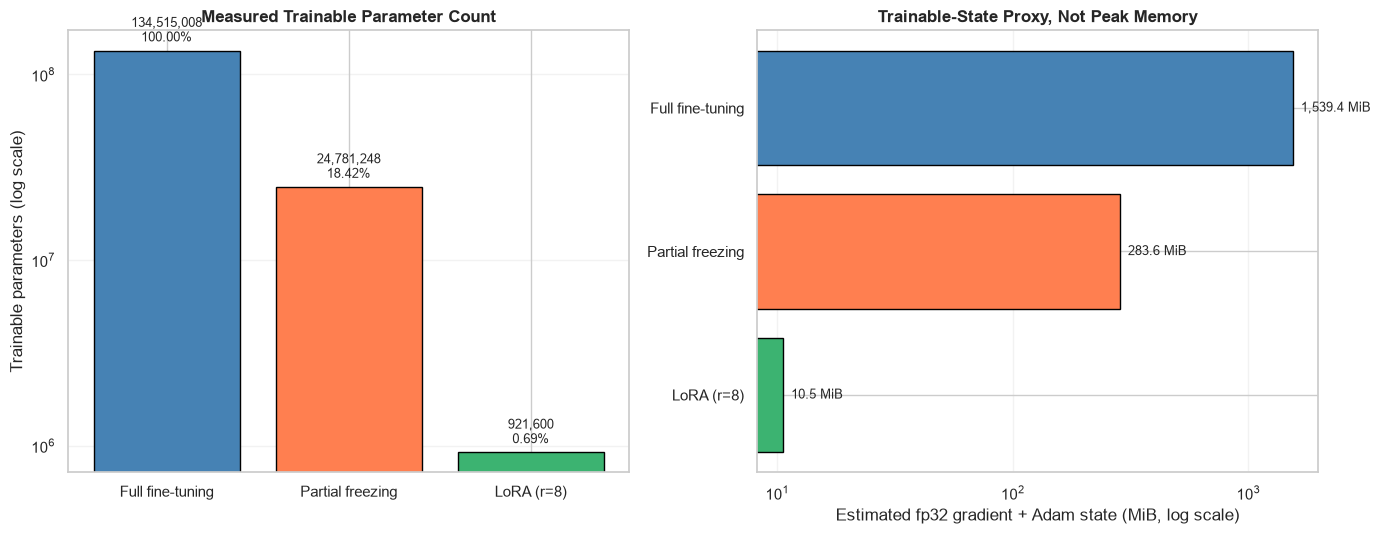

Technique                   Trainable    Percent    Grad+Adam proxy
--------------------------------------------------------------------
Full fine-tuning          134,515,008    100.00%         1,539.4 MiB
Partial freezing           24,781,248     18.42%           283.6 MiB
LoRA (r=8)                    921,600      0.69%            10.5 MiB

Boundary: this proxy excludes resident weights, activations, temporary buffers, and hardware effects.
Trainable-parameter ratios do not establish peak memory, elapsed time, throughput, or quality.

RIVERSIDE TAKEAWAY
Full FT: maximum freedom, complete per-job model.
Partial freezing: smaller update state, still a complete per-job model.
LoRA: one shared base plus a small per-job adapter.
QLoRA: use when the shared frozen base itself is the memory blocker.


In [36]:
# Compare measured trainable counts and an explicitly bounded update-state proxy.
total_params = sum(parameter.numel() for parameter in base_model.parameters())
full_ft_params = total_params
partial_ft_params = sum(
    parameter.numel() for parameter in freeze_model.parameters() if parameter.requires_grad
)
lora_params = sum(
    parameter.numel() for parameter in lora_pt_model.parameters() if parameter.requires_grad
)

techniques = ["Full fine-tuning", "Partial freezing", "LoRA (r=8)"]
param_counts = [full_ft_params, partial_ft_params, lora_params]
param_pcts = [count / total_params * 100 for count in param_counts]
colors = ["steelblue", "coral", "mediumseagreen"]

# fp32 gradient (4 bytes) + two fp32 Adam moments (8 bytes) per trainable parameter.
# Model weights, activations, temporary buffers, and allocator overhead are deliberately excluded.
update_state_bytes_per_param = 12
update_state_mb = [
    count * update_state_bytes_per_param / 1024**2 for count in param_counts
]

fig, (count_axis, state_axis) = plt.subplots(1, 2, figsize=(14, 5.5))

count_bars = count_axis.bar(techniques, param_counts, color=colors, edgecolor="black")
count_axis.set_yscale("log")
count_axis.set_ylabel("Trainable parameters (log scale)")
count_axis.set_title("Measured Trainable Parameter Count", fontweight="bold")
count_axis.grid(axis="y", alpha=0.25)
for bar, count, percent in zip(count_bars, param_counts, param_pcts):
    count_axis.annotate(
        f"{count:,}\n{percent:.2f}%",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

state_bars = state_axis.barh(techniques, update_state_mb, color=colors, edgecolor="black")
state_axis.invert_yaxis()
state_axis.set_xscale("log")
state_axis.set_xlabel("Estimated fp32 gradient + Adam state (MiB, log scale)")
state_axis.set_title("Trainable-State Proxy, Not Peak Memory", fontweight="bold")
state_axis.grid(axis="x", alpha=0.25)
for bar, state_mb in zip(state_bars, update_state_mb):
    state_axis.annotate(
        f"{state_mb:,.1f} MiB",
        xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

print(f"{'Technique':<22} {'Trainable':>14} {'Percent':>10} {'Grad+Adam proxy':>18}")
print("-" * 68)
for technique, count, percent, state_mb in zip(
    techniques, param_counts, param_pcts, update_state_mb
):
    print(f"{technique:<22} {count:>14,} {percent:>9.2f}% {state_mb:>15,.1f} MiB")

print("\nBoundary: this proxy excludes resident weights, activations, temporary buffers, and hardware effects.")
print("Trainable-parameter ratios do not establish peak memory, elapsed time, throughput, or quality.")
print("\nRIVERSIDE TAKEAWAY")
print("Full FT: maximum freedom, complete per-job model.")
print("Partial freezing: smaller update state, still a complete per-job model.")
print("LoRA: one shared base plus a small per-job adapter.")
print("QLoRA: use when the shared frozen base itself is the memory blocker.")

### Memory Anatomy: What Shrinks, and What Does Not?

Trainable-parameter count explains only the **update-state** portion of memory. A training step may also hold resident weights, activations, temporary workspaces, and framework overhead.

The next chart builds an intentionally idealized fp32 anatomy from the measured parameter counts:

- resident model weights: 4 bytes per value;
- gradients: 4 bytes per trainable value;
- Adam moments: 8 bytes per trainable value; and
- QLoRA frozen base: an idealized 4-bit floor plus fp32 adapter state.

This is a structural comparison, not a claim about peak GPU memory. Real NF4 storage adds quantization metadata; activations depend on sequence length, batch size, checkpointing, and kernels; allocator overhead is hardware/runtime specific. Measure peak allocated and reserved memory in the matched Part 3 experiment before making a deployment decision.

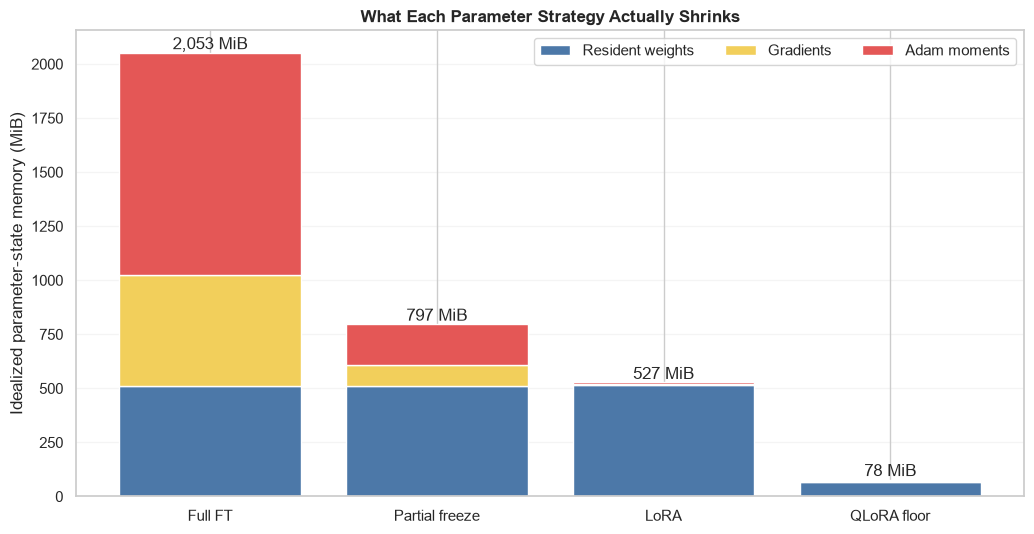

Boundary: excludes activations, temporary buffers, quantization metadata, and allocator overhead.
QLoRA floor uses 0.5 byte/base value only to expose the direction of the resident-base change.


In [37]:
# Idealized memory anatomy derived from measured parameter counts; not peak-memory telemetry.
strategy_labels = ["Full FT", "Partial freeze", "LoRA", "QLoRA floor"]
resident_weight_mib = [
    total_params * 4 / 1024**2,
    total_params * 4 / 1024**2,
    total_params * 4 / 1024**2 + lora_params * 4 / 1024**2,
    total_params * 0.5 / 1024**2 + lora_params * 4 / 1024**2,
]
trainable_for_anatomy = [full_ft_params, partial_ft_params, lora_params, lora_params]
gradient_mib = [count * 4 / 1024**2 for count in trainable_for_anatomy]
adam_mib = [count * 8 / 1024**2 for count in trainable_for_anatomy]

figure, memory_axis = plt.subplots(figsize=(10.5, 5.5))
indices = np.arange(len(strategy_labels))
memory_axis.bar(indices, resident_weight_mib, label="Resident weights", color="#4C78A8")
memory_axis.bar(
    indices,
    gradient_mib,
    bottom=resident_weight_mib,
    label="Gradients",
    color="#F2CF5B",
)
update_bottom = np.array(resident_weight_mib) + np.array(gradient_mib)
memory_axis.bar(
    indices,
    adam_mib,
    bottom=update_bottom,
    label="Adam moments",
    color="#E45756",
)
totals_mib = update_bottom + np.array(adam_mib)
for index, total_mib in enumerate(totals_mib):
    memory_axis.text(index, total_mib, f"{total_mib:,.0f} MiB", ha="center", va="bottom")

memory_axis.set_xticks(indices, strategy_labels)
memory_axis.set_ylabel("Idealized parameter-state memory (MiB)")
memory_axis.set_title("What Each Parameter Strategy Actually Shrinks", fontweight="bold")
memory_axis.legend(ncol=3, loc="upper right")
memory_axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print("Boundary: excludes activations, temporary buffers, quantization metadata, and allocator overhead.")
print("QLoRA floor uses 0.5 byte/base value only to expose the direction of the resident-base change.")

### Optional Storage Exercise: Dynamic Int8 Conversion

Post-training dynamic int8 conversion is not QLoRA training. It is included only to make one storage distinction tangible: a trained floating-point checkpoint can be converted into a different CPU-oriented representation after training.

The exercise below loads one full checkpoint, converts supported linear layers, and compares serialized parameter-state size. It does not generate text or interpret model behavior. Part 3 owns all evaluation.

For the wider method catalog, see [Quantization in Depth](../../ai-infrastructure/06-quantization/quantization-in-depth.ipynb).

> **PyTorch → Keras:** `torch.quantization.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)` converts supported linear weights to int8 for CPU inference. TensorFlow's closest equivalent uses the TFLite converter with `tf.lite.Optimize.DEFAULT`, producing a separate `.tflite` artifact rather than changing the in-memory Keras model.

In [38]:
# CPU-native post-training conversion: inspect representation and serialized size only.
import io

full_checkpoint_dir = CHECKPOINT_DIR / "non-instruction-full"
config_path = full_checkpoint_dir / "config.json"
fp32_model = None
int8_model = None

if not config_path.is_file():
    print(
        "SKIP: the optional int8 storage exercise needs the Part 1 continued-pretraining "
        f"checkpoint at {full_checkpoint_dir}. Run Part 1 first."
    )
else:
    full_checkpoint_config = json.loads(config_path.read_text(encoding="utf-8"))
    if full_checkpoint_config.get("model_type") != base_model.config.model_type:
        raise RuntimeError(
            "The continued-pretraining checkpoint uses an incompatible architecture. "
            "Regenerate Part 1 checkpoints for this model profile."
        )
    fp32_model = AutoModelForCausalLM.from_pretrained(full_checkpoint_dir)
    fp32_model.eval()
    int8_model = torch.quantization.quantize_dynamic(
        fp32_model, {torch.nn.Linear}, dtype=torch.qint8
    )


def state_dict_size_mb(model):
    """Measure serialized parameter-state size without writing a temporary artifact."""
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    return buffer.getbuffer().nbytes / 1e6


if fp32_model is not None and int8_model is not None:
    fp32_mb = state_dict_size_mb(fp32_model)
    int8_mb = state_dict_size_mb(int8_model)
    print(f"fp32 state_dict size: {fp32_mb:.1f} MB")
    print(f"int8 state_dict size: {int8_mb:.1f} MB")
    print(f"Serialized state reduction: {(1 - int8_mb / fp32_mb) * 100:.1f}%")

    quantized_linear_count = sum(
        "quantized" in type(module).__module__ and type(module).__name__ == "Linear"
        for module in int8_model.modules()
    )
    print(f"Dynamically quantized linear modules: {quantized_linear_count}")
    print("Part 3 owns runtime and behavioral evaluation of converted artifacts.")

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3191.55it/s]


fp32 state_dict size: 269.1 MB
int8 state_dict size: 191.4 MB
Serialized state reduction: 28.9%
Dynamically quantized linear modules: 211
Part 3 owns runtime and behavioral evaluation of converted artifacts.


---

## Riverside Takeaway: Choose the Smallest Total Bill That Fits the Job

The parameter mechanisms are now visible:

| Strategy | What receives gradients | What the adaptation saves | Capability-regression and recovery bill |
| --- | --- | --- | --- |
| Full fine-tuning | Every trainable model weight | A complete changed checkpoint | Broad retention suite; rollback replaces the model; remediation may require replay, retraining, and redeployment |
| Partial freezing | A selected layer slice | A complete changed checkpoint | Narrower writable surface, but retention tests and full-artifact rollback remain |
| LoRA | Small $A$ and $B$ matrices beside frozen projections | A compact adapter plus a pinned base dependency | Active adapter still needs regression tests; disabling it restores the unchanged base immediately |
| QLoRA path | Floating-point LoRA matrices beside a compact frozen base | Adapter plus a compatible low-bit base/runtime contract | Keeps adapter-local rollback and adds low-bit quality validation against the full-precision base |

Riverside does not win by choosing the fanciest technique or the smallest parameter count in isolation. It wins by minimizing the total bill while meeting target and retained-capability requirements:

- choose full fine-tuning when maximum update freedom justifies full state, artifact, regression-testing, and recovery costs;
- choose partial freezing when a known layer slice is enough and complete-checkpoint recovery remains acceptable;
- choose LoRA when many jobs should share one base and cheap rollback matters; and
- choose QLoRA when the frozen base's resident-memory bill blocks deployment and the low-bit validation bill is acceptable.

Continue to **[Part 3: Evaluation, Comparison & Decision](03-llm-finetuning-comparison-and-decision.ipynb)**. There, every candidate must pay two gates before cost comparison: prove the target behavior improved and prove retained capabilities remain acceptable. A failed retention gate is not an add-on observation; it is a capability-regression charge that includes remediation or rejection of the candidate.